
# Integración geométrica de una partícula cargada en un campo eléctrico dependiente del tiempo (1D)
## Extensión Hamiltoniana · Splitting · Integrador de Strang

Este cuaderno estudia numéricamente la dinámica de una partícula cargada en $\mathbb{R}$
bajo la acción de un campo eléctrico homogéneo dependiente del tiempo, usando:

1. **Extensión Hamiltoniana** para convertir un sistema no autónomo en uno autónomo symplectico.
2. **Splitting del Hamiltoniano extendido** en partes con flujo integrable.
3. **Integrador symplectico de Strang** (composición simétrica).
4. **Comparación con RK4**, análisis de energía, orden y volumen de fase.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from numpy.linalg import norm, det
plt.style.use("seaborn-v0_8")



## 1. Modelo físico y Hamiltoniano no autónomo (1D)

Consideramos una partícula de masa $m$ y carga $e$ moviéndose en $\mathbb{R}$ con posición
$q \in \mathbb{R}$ y momento $p \in \mathbb{R}$. El campo eléctrico es homogéneo en el espacio
y depende del tiempo $t$, denotado por $E(t) \in \mathbb{R}$.

El Hamiltoniano no autónomo es
$$
H(q,p,t) = \frac{p^2}{2m} - e\, q\,E(t).
$$


Las ecuaciones de Hamilton son
$$
\dot q = \frac{p}{m}, \qquad
\dot p = e\,E(t), \qquad
\dot t = 1.
$$


In [2]:
m = 1.0
e = 1.0

def make_field(omega=0.5):
    def E(t):
        return np.sin(omega * t)
    def E_dot(t):
        return omega * np.cos(omega * t)
    return E, E_dot

omega_base = 0.5
E_func, E_dot_func = make_field(omega_base)

def H_physical(q, p, t):
    return 0.5 * (p**2) / m - e * q * E_func(t)



## 2. Extensión Hamiltoniana y splitting (1D)


In [3]:
def strang_step(q, p, t, Eext, dt, E_func, E_dot_func):
    q = q + 0.5 * dt * (p / m)
    t = t + 0.5 * dt * 0.5

    t_mid = t + 0.5 * dt * 0.5
    p = p + dt * e * E_func(t_mid)
    Eext = Eext + dt * e * q * E_dot_func(t_mid)
    t = t + dt * 0.5

    q = q + 0.5 * dt * (p / m)
    t = t + 0.5 * dt * 0.5

    return q, p, t, Eext


In [4]:
def rk4_step(q, p, t, dt, E_func):
    def f_q(p): return p/m
    def f_p(t): return e * E_func(t)

    k1q = f_q(p)
    k1p = f_p(t)

    k2q = f_q(p + 0.5*dt*k1p)
    k2p = f_p(t + 0.5*dt)

    k3q = f_q(p + 0.5*dt*k2p)
    k3p = f_p(t + 0.5*dt)

    k4q = f_q(p + dt*k3p)
    k4p = f_p(t + dt)

    q_new = q + dt*(k1q + 2*k2q + 2*k3q + k4q)/6
    p_new = p + dt*(k1p + 2*k2p + 2*k3p + k4p)/6

    return q_new, p_new, t + dt


In [5]:
def simulate_strang(q0, p0, t0, E0, dt, steps, E_func, E_dot_func):
    q, p, t, Eext = q0, p0, t0, E0

    traj, mom, times = [], [], []
    Hs, Hexts = [], []

    for _ in range(steps):

        # ---- avance del estado ----
        q, p, t, Eext = strang_step(q, p, t, Eext, dt, E_func, E_dot_func)
        
        # ---- registrar después del flujo ----
        traj.append(q)
        mom.append(p)
        times.append(t)

        H = H_physical(q, p, t)
        Hs.append(H)
        Hexts.append(H + Eext)

    return (np.array(traj), np.array(mom),
            np.array(times), np.array(Hs), np.array(Hexts))


def simulate_rk4(q0, p0, t0, dt, steps, E_func):
    q, p, t = q0, p0, t0
    traj, mom, times, Hs = [], [], [], []
    for _ in range(steps):
        traj.append(q)
        mom.append(p)
        times.append(t)
        Hs.append(H_physical(q, p, t))
        q, p, t = rk4_step(q, p, t, dt, E_func)
    return np.array(traj), np.array(mom), np.array(times), np.array(Hs)



## 3. Backward error analysis (BEA)



El backward error analysis para integradores symplecticos dice que el método numérico
no sigue exactamente el flujo del Hamiltoniano original $\widehat H$, sino el de un
Hamiltoniano modificado cercano:
$$
\widehat H_{\text{mod}} = \widehat H + \Delta t^2 H_2 + \Delta t^4 H_4 + \cdots.
$$
Esto explica la casi-conservación de la energía extendida y la buena preservación
de la estructura geométrica.


In [6]:
dt = 0.01
steps = 4000

q0 = 0.0
p0 = 1.0
t0 = 0.0
E0 = 0.0

traj_s, mom_s, times_s, H_s, Hext_s = simulate_strang(
    q0, p0, t0, E0, dt, steps, E_func, E_dot_func
)
traj_r, mom_r, times_r, H_r = simulate_rk4(
    q0, p0, t0, dt, steps, E_func
)



## 4. Resultados: Strang vs RK4


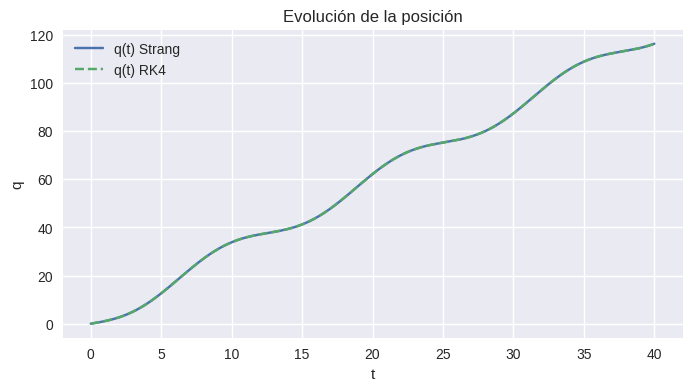

In [7]:
plt.figure(figsize=(8,4))
plt.plot(times_s, traj_s, label="q(t) Strang")
plt.plot(times_r, traj_r, '--', label="q(t) RK4")
plt.title("Evolución de la posición")
plt.xlabel("t"); plt.ylabel("q")
plt.legend(); plt.grid(True)
plt.show()

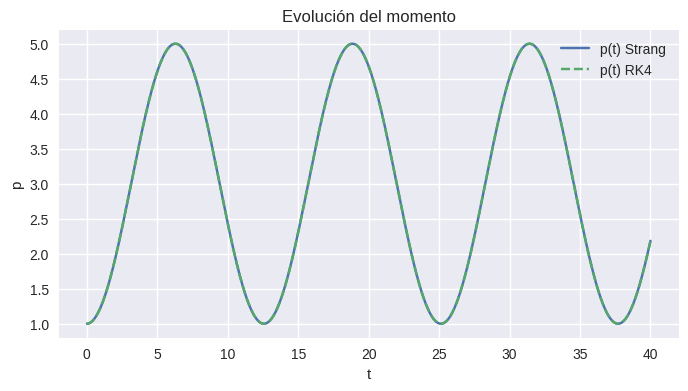

In [8]:
plt.figure(figsize=(8,4))
plt.plot(times_s, mom_s, label="p(t) Strang")
plt.plot(times_r, mom_r, '--', label="p(t) RK4")
plt.title("Evolución del momento")
plt.xlabel("t"); plt.ylabel("p")
plt.legend(); plt.grid(True)
plt.show()

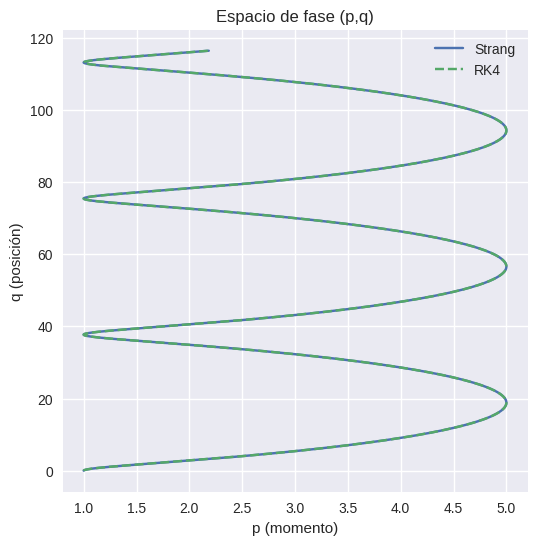

In [9]:
plt.figure(figsize=(6,6))
plt.plot(mom_s, traj_s, label="Strang")     
plt.plot(mom_r, traj_r, '--', label="RK4")
plt.title("Espacio de fase (p,q)")
plt.xlabel("p (momento)")
plt.ylabel("q (posición)")
plt.legend()
plt.grid(True)
plt.show()


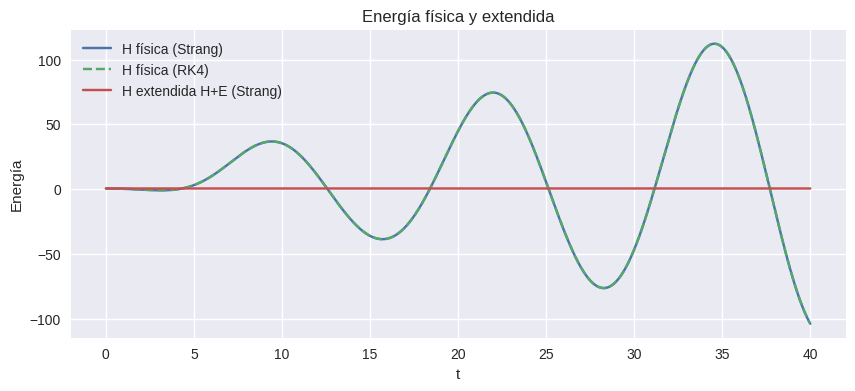

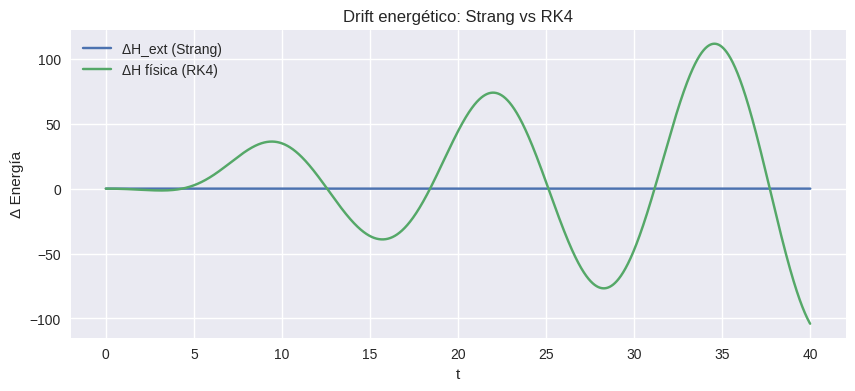

In [10]:
H_s = np.array(H_s)
H_r = np.array(H_r)
Hext_s = np.array(Hext_s)

plt.figure(figsize=(10,4))
plt.plot(times_s, H_s,label="H física (Strang)")
plt.plot(times_r, H_r, '--',label="H física (RK4)")
plt.plot(times_s, Hext_s, label="H extendida H+E (Strang)")
plt.title("Energía física y extendida")
plt.xlabel("t"); plt.ylabel("Energía")
plt.legend(); plt.grid(True)
plt.show()

err_energy_strang = Hext_s - Hext_s[0]
err_energy_rk4 = H_r - H_r[0]

plt.figure(figsize=(10,4))
plt.plot(times_s, err_energy_strang, label="ΔH_ext (Strang)")
plt.plot(times_r, err_energy_rk4, label="ΔH física (RK4)")
plt.title("Drift energético: Strang vs RK4")
plt.xlabel("t"); plt.ylabel("Δ Energía")
plt.legend(); plt.grid(True)
plt.show()



## 5. Orden del método: error vs $\Delta t$


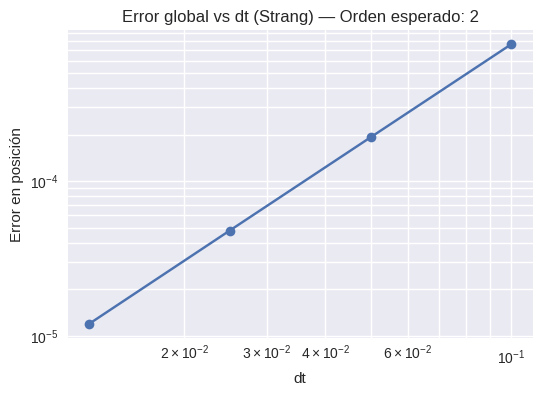

In [11]:
T = 2.0
dt_ref = 0.001
steps_ref = int(T/dt_ref)

traj_ref, _, _, _, _ = simulate_strang(q0, p0, t0, E0, dt_ref, steps_ref, E_func, E_dot_func)
q_ref = traj_ref[-1]

dts = [0.1, 0.05, 0.025, 0.0125]
errors = []

for dt_test in dts:
    steps_test = int(T/dt_test)
    traj_test, _, _, _, _ = simulate_strang(q0, p0, t0, E0, dt_test, steps_test, E_func, E_dot_func)
    q_test = traj_test[-1]
    errors.append(norm(q_test - q_ref))

plt.figure(figsize=(6,4))
plt.loglog(dts, errors, 'o-')
plt.title("Error global vs dt (Strang) — Orden esperado: 2")
plt.xlabel("dt"); plt.ylabel("Error en posición")
plt.grid(True, which="both")
plt.show()



## 6. Preservación de volumen: Jacobiano (1D)


In [12]:
eps = 1e-6

def jacobian_step_1d(q, p, t, Eext, dt, E_func, E_dot_func, eps=eps):
    x = np.array([q, p, t, Eext])
    n = 4
    J = np.zeros((n, n))
    q0, p0, t0, E0 = strang_step(q, p, t, Eext, dt, E_func, E_dot_func)
    f0 = np.array([q0, p0, t0, E0])

    for i in range(n):
        dx = np.zeros_like(x)
        dx[i] = eps
        q1, p1, t1, E1 = strang_step(
            x[0] + dx[0], x[1] + dx[1],
            x[2] + dx[2], x[3] + dx[3],
            dt, E_func, E_dot_func
        )
        f = np.array([q1, p1, t1, E1])
        J[:, i] = (f - f0) / eps

    return J

J = jacobian_step_1d(q0, p0, t0, E0, dt, E_func, E_dot_func)
detJ = det(J)
print(f"det(J) ≈ {detJ:.6f}")
print(f"Error relativo |det(J)-1| ≈ {abs(detJ-1):.3e}")


det(J) ≈ 1.000000
Error relativo |det(J)-1| ≈ 8.200e-11



## 7. Resonancia paramétrica (1D)


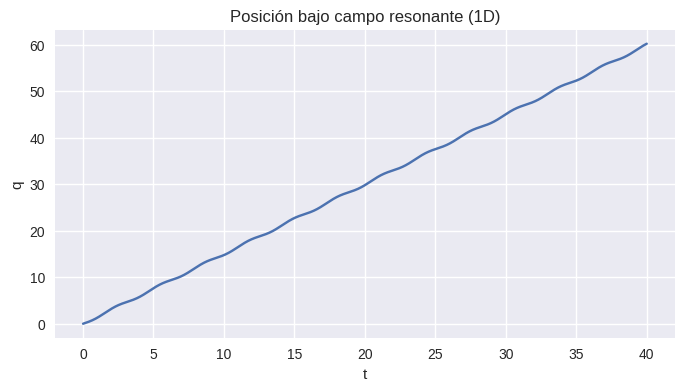

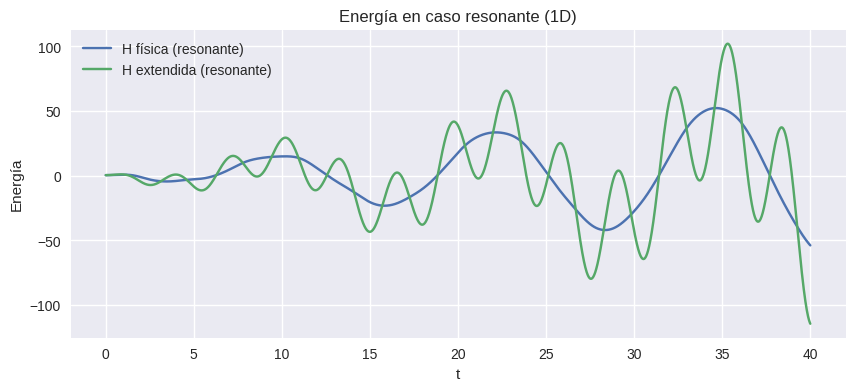

In [13]:
omega_res = 2.0
E_res, E_res_dot = make_field(omega_res)

traj_res, mom_res, times_res, H_res, Hext_res = simulate_strang(
    q0, p0, t0, E0, dt, steps, E_res, E_res_dot
)

plt.figure(figsize=(8,4))
plt.plot(times_res, traj_res)
plt.title("Posición bajo campo resonante (1D)")
plt.xlabel("t"); plt.ylabel("q")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(times_res, H_res, label="H física (resonante)")
plt.plot(times_res, Hext_res, label="H extendida (resonante)")
plt.title("Energía en caso resonante (1D)")
plt.xlabel("t"); plt.ylabel("Energía")
plt.legend(); plt.grid(True)
plt.show()



## 8. Animación de la posición (Strang, 1D)


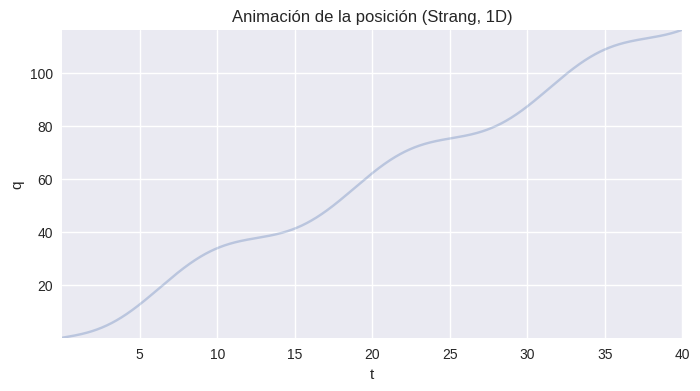

In [14]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(times_s, traj_s, alpha=0.3)
ax.set_xlim(times_s[0], times_s[-1])
ax.set_ylim(traj_s.min(), traj_s.max())
ax.set_xlabel("t"); ax.set_ylabel("q")
ax.set_title("Animación de la posición (Strang, 1D)")
ax.grid(True)

point, = ax.plot([], [], 'o')

def update(i):
    point.set_data(times_s[i], traj_s[i])
    return point,

ani = animation.FuncAnimation(fig, update, frames=len(traj_s), interval=10)
plt.show()



## 9. Conclusiones

1. El integrador symplectico por extensión Hamiltoniana y splitting de Strang
   muestra buena conservación de la energía extendida y del volumen de fase
   en el caso 1D.
2. RK4 presenta drift energético apreciable a largo plazo.
3. El análisis de error global confirma empíricamente que el método de Strang es de
   orden 2.
4. La resonancia paramétrica ilustra cómo el método preserva fenómenos cualitativos
   en línea con la teoría geométrica.
